# Checkpoints em workflows

Checkpoints são snapshots de estados em determinados momentos. Eles são usados para diversas coisas, como time travel, 
ou seja, voltar em um estado específico, ou manter coesão em super steps

### Criando classe do estado

In [1]:
from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

### Criando nós

In [2]:
def node_a(state: State) -> State:
    print("Rodando o nó A")
    return {
        "foo": "eaí jão",
        "bar": ["eaí jão"]
    }

def node_b(state: State) -> State:
    print("Rodando o nó B")
    return {
        "foo": "eaí maria",
        "bar": ["eaí maria"]
    }

### Criando estrutura do workflow

In [4]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

graph_builder = StateGraph(State)

graph_builder.add_node("node_a", node_a)
graph_builder.add_node("node_b", node_b)

graph_builder.add_edge(START, "node_a")
graph_builder.add_edge("node_a", "node_b")
graph_builder.add_edge("node_b", END)

checkpointer = InMemorySaver()

graph_compiled = graph_builder.compile(checkpointer=checkpointer)

### Visualizando grafo

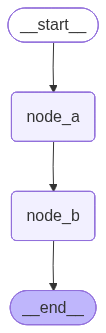

In [5]:
from IPython.display import display, Image

display(Image(graph_compiled.get_graph().draw_mermaid_png()))

### Executando o grafo

In [13]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

state = {
    "foo": ""
}

In [14]:
response = graph_compiled.invoke(input=state, config=config)

Rodando o nó A
Rodando o nó B


In [15]:
response

{'foo': 'eaí maria', 'bar': ['eaí jão', 'eaí maria', 'eaí jão', 'eaí maria']}

# Olhando as propriedades do checkpointer

### Pegando por thread_id

In [16]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

states = graph_compiled.get_state(config=config)

In [17]:
print(states)

StateSnapshot(values={'foo': 'eaí maria', 'bar': ['eaí jão', 'eaí maria', 'eaí jão', 'eaí maria']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed5-6a59-8006-c1cc6105eb9d'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2025-10-28T16:39:11.725620+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed3-6cec-8005-bd5a41885cc1'}}, tasks=(), interrupts=())


### Pegando o checkpoint_id

In [18]:
config = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f0b41ca-1ed5-6a59-8006-c1cc6105eb9d"
    }
}

states = graph_compiled.get_state(config=config)

In [19]:
states

StateSnapshot(values={'foo': 'eaí maria', 'bar': ['eaí jão', 'eaí maria', 'eaí jão', 'eaí maria']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0b41ca-1ed5-6a59-8006-c1cc6105eb9d'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2025-10-28T16:39:11.725620+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed3-6cec-8005-bd5a41885cc1'}}, tasks=(), interrupts=())

### Acessando o histórico todo

In [20]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

states = graph_compiled.get_state_history(config=config)

In [22]:
for x in list(states):
    print(x)

StateSnapshot(values={'foo': 'eaí maria', 'bar': ['eaí jão', 'eaí maria', 'eaí jão', 'eaí maria']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed5-6a59-8006-c1cc6105eb9d'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2025-10-28T16:39:11.725620+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed3-6cec-8005-bd5a41885cc1'}}, tasks=(), interrupts=())
StateSnapshot(values={'foo': 'eaí jão', 'bar': ['eaí jão', 'eaí maria', 'eaí jão']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed3-6cec-8005-bd5a41885cc1'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2025-10-28T16:39:11.724861+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b41ca-1ed1-60ae-8004-094c22e4b78a'}}, tasks=(PregelTask(id='f5d86b01-8167-c09f-a8a0-6b64e0c